# Ethiopia EDA

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats



# Load Data

In [3]:
df = pd.read_csv("../data/ethiopia.csv")
df["Country"] = "Ethiopia"
df.head()


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia


In [ ]:
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["Date"].dt.month
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1


## Clean

In [10]:
df.replace(-999, np.nan, inplace=True)

In [ ]:
print(df.duplicated(), '\n')
print(f"How many duplicates: {df.duplicated().sum()}")

df = df.drop_duplicates()

0       False
1       False
2       False
3       False
4       False
        ...  
4103    False
4104    False
4105    False
4106    False
4107    False
Length: 4108, dtype: bool 

How many duplicates: 0


In [21]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN,3.477046


# Summary statistics
this is the summmary statistics of all numeric columns

In [31]:
missing = df.isna().sum()#this will give us the percentage of missing values in each column
missing_percent = (missing/len(df)) * 100

high_missing = missing_percent[missing_percent > 5]

if high_missing.empty:
    summary = pd.DataFrame(
        {
            "Missing Count": missing,
            "Missing Percent": missing_percent
        }
    )
    display(summary)

,Missing Count,Missing Percent
YEAR,0,0.0
DOY,0,0.0
T2M,0,0.0
T2M_MAX,0,0.0
T2M_MIN,0,0.0
T2M_RANGE,0,0.0
PRECTOTCORR,0,0.0
RH2M,0,0.0
WS2M,0,0.0
WS2M_MAX,0,0.0


## Outliers

In [ ]:
cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

z_scores = np.abs(stats.zscore(df[cols].dropna(),nan_policy='omit'))
z_df = pd.DataFrame(z_scores, index=df[cols].dropna().index, columns=cols)

outlier_mask = (z_scores > 3).any(axis=1)
print((z_scores > 3).sum())
'''

df = df[df.isna().mean(axis=1) <= 0.3].copy()
df[weather_cols] = df[weather_cols].ffill().bfill()

if 'T2M_RANGE' not in df.columns:
        df['T2M_RANGE'] = df['T2M_MAX'] - df['T2M_MIN']
        
df.to_csv('../data/ethiopia_clean.csv', index=False)
print('saved')



'''

137


"\n\ndf = df[df.isna().mean(axis=1) <= 0.3].copy()\ndf[weather_cols] = df[weather_cols].ffill().bfill()\n\nif 'T2M_RANGE' not in df.columns:\n        df['T2M_RANGE'] = df['T2M_MAX'] - df['T2M_MIN']\n\ndf.to_csv('../data/ethiopia_clean.csv', index=False)\nprint('saved')\n"

### Outlier Treatment: Retain

**Decision:** I have decided to **retain** the 137 identified outlier rows.

**Reasoning:**
* **Data Authenticity:** In weather data (`T2M`, `PRECTOTCORR`), extremes are often real environmental events (storms or heatwaves) rather than errors.
* **Seasonal Integrity:** Removing these would bias the seasonal analysis by hiding the natural variability of the climate.
* **Model Robustness:** Retaining them ensures the analysis reflects real-world conditions, including high-impact weather peaks.

In [60]:
for col in cols:
    upper = df[col].mean() + 3 * df[col].std()
    lower = df[col].mean() - 3 * df[col].std()
    df[col] = np.clip(df[col], lower, upper)

# 1. Drop rows with more than 30% missing values
df = df.dropna(thresh=int(0.7 * len(df.columns)))
# 2. Forward-fill remaining weather variables
df.fillna(method="ffill", inplace=True)
# 3. Export to CSV (replace 'Ethiopia' with your country name)
df.to_csv("../data/ethiopia_clean.csv", index=False)

C:\Users\HP\AppData\Local\Temp\ipykernel_27112\3545118969.py:9: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method="ffill", inplace=True)


## Time series

1. Monthly Average T2M (Line Chart)


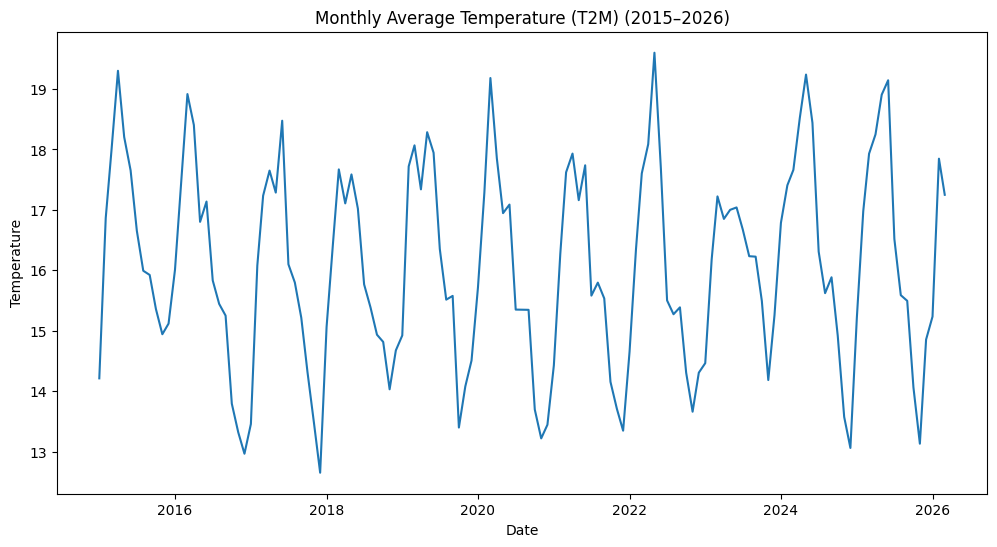

In [83]:
monthly_t2m = df.groupby(["YEAR", "Month"])["T2M"].mean().reset_index()

#Create a proper date for plotting
monthly_t2m["Date"] = pd.to_datetime(monthly_t2m["YEAR"].astype(str) + "-" + monthly_t2m["Month"].astype(str))

#Plot line chart
plt.figure(figsize=(12,6))
plt.plot(monthly_t2m["Date"], monthly_t2m["T2M"])
plt.title("Monthly Average Temperature (T2M) (2015–2026)")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.show()



Annotate Warmest & Coolest Months

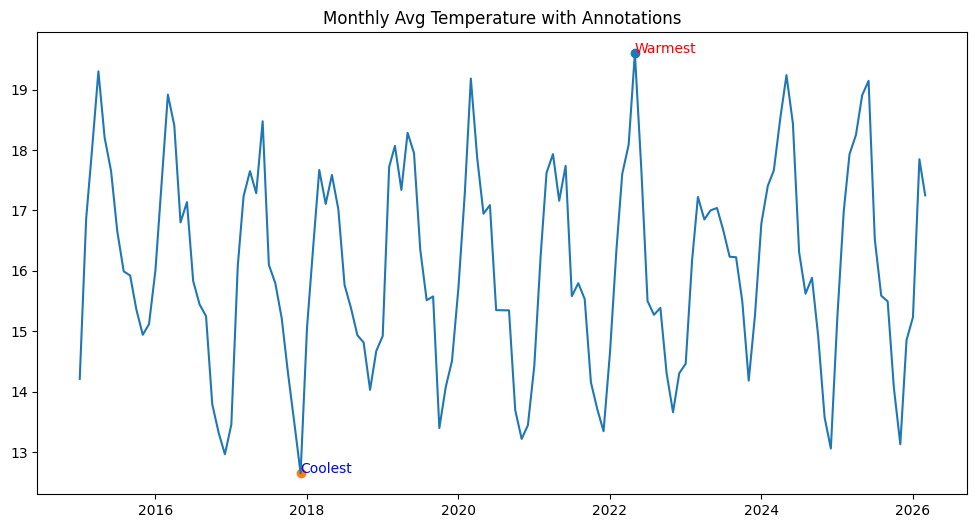

In [84]:
#Annotate Warmest & Coolest Months
max_row = monthly_t2m.loc[monthly_t2m["T2M"].idxmax()]
min_row = monthly_t2m.loc[monthly_t2m["T2M"].idxmin()]

plt.figure(figsize=(12,6))
plt.plot(monthly_t2m["Date"], monthly_t2m["T2M"])

plt.scatter(max_row["Date"], max_row["T2M"])
plt.text(max_row["Date"], max_row["T2M"], "Warmest", color="red")

plt.scatter(min_row["Date"], min_row["T2M"])
plt.text(min_row["Date"], min_row["T2M"], "Coolest", color="blue")

plt.title("Monthly Avg Temperature with Annotations")
plt.show()

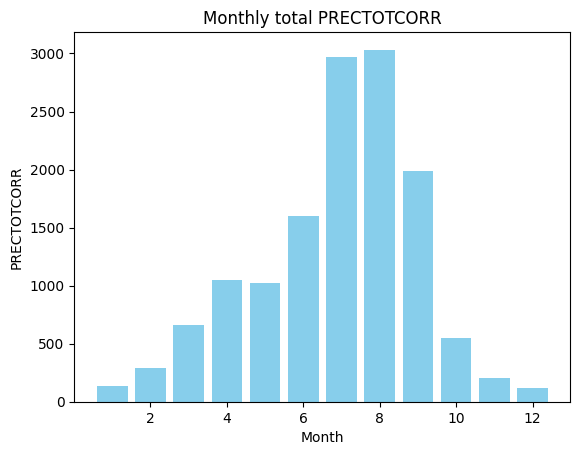

In [85]:

#Monthly Total PRECTOTCORR (Bar Chart)
monthly_precip = df.groupby('Month')['PRECTOTCORR'].sum()
plt.figure()
plt.bar(monthly_precip.index, monthly_precip.values, color='skyblue')
plt.title('Monthly total PRECTOTCORR')
plt.xlabel('Month')
plt.ylabel('PRECTOTCORR')
plt.show()



## Correlation

Correlation Heatmap

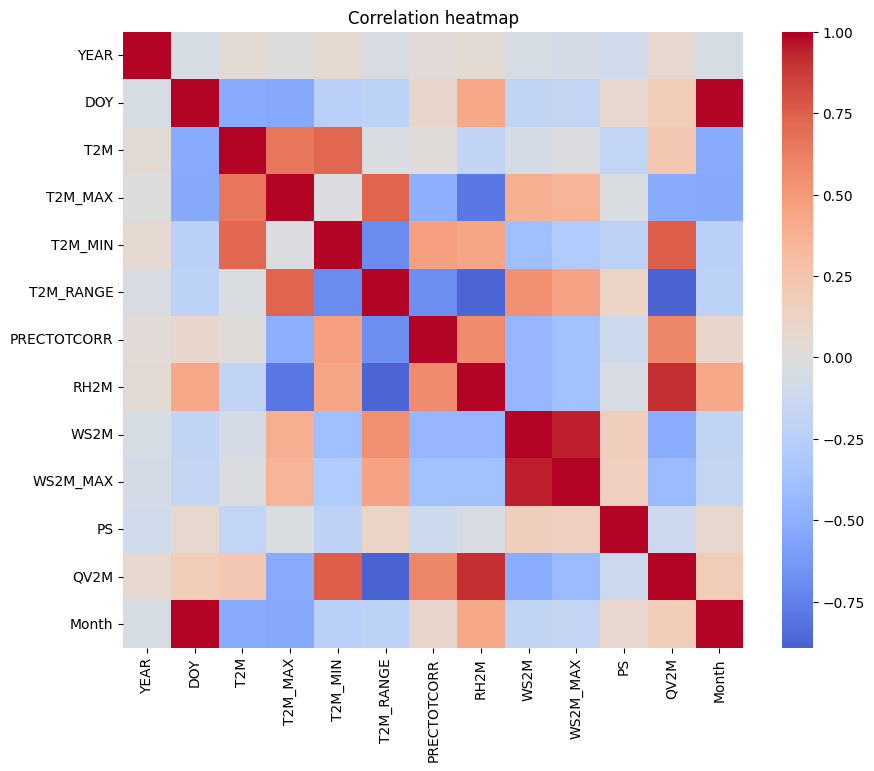

In [87]:
num = df.select_dtypes(include=[np.number])
corr = num.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title('Correlation heatmap')
plt.show()

Scatter Plot: T2M vs RH2M

DOY       Month    0.996557
Month     DOY      0.996557
WS2M_MAX  WS2M     0.940931
dtype: float64


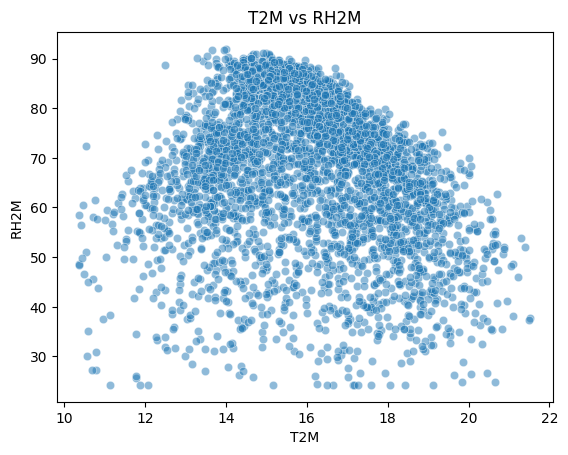

In [88]:
print(corr.unstack().sort_values(ascending=False)[len(corr):len(corr)+3])
plt.figure()
sns.scatterplot(data=df, x='T2M', y='RH2M', alpha=0.5)
plt.title('T2M vs RH2M')
plt.show()

Scatter Plot: T2M_RANGE vs WS2M

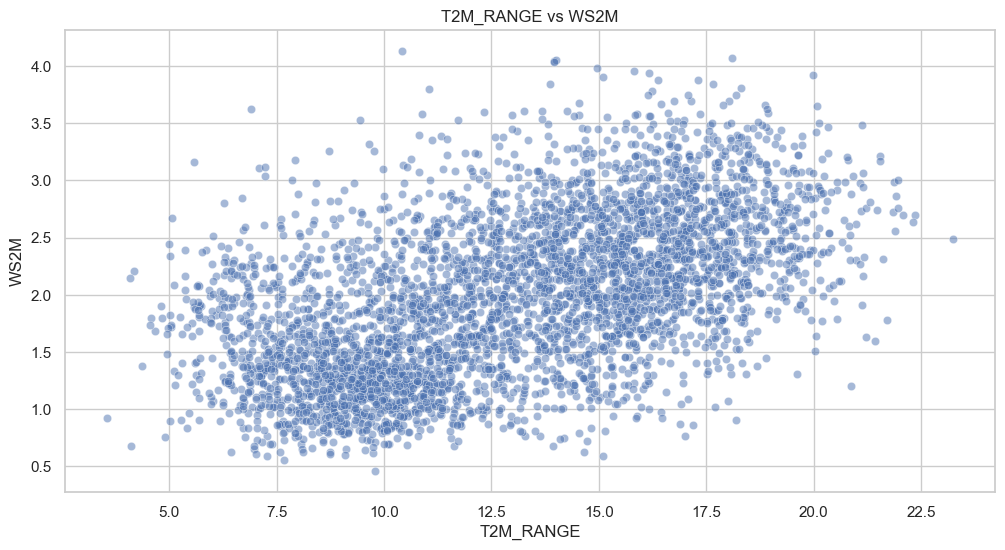

In [9]:

plt.figure()
sns.scatterplot(data=df, x='T2M_RANGE', y='WS2M', alpha=0.5)
plt.title('T2M_RANGE vs WS2M')
plt.show()


## Distribution

Histogram of PRECTOTCORR

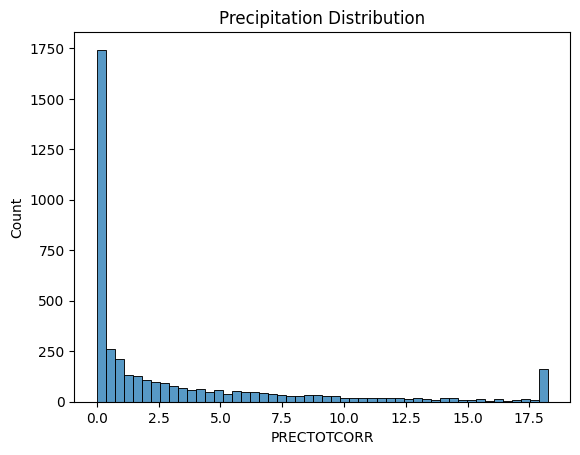

In [89]:
sns.histplot(df["PRECTOTCORR"], bins=50)
plt.title("Precipitation Distribution")
plt.show()

If skewed → log scale
Right-skewed (positively skewed)

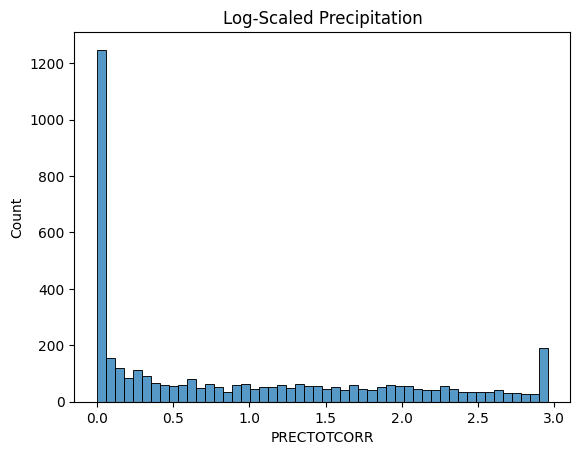

In [91]:
sns.histplot(np.log1p(df["PRECTOTCORR"]), bins=50)
plt.title("Log-Scaled Precipitation")
plt.show()

Bubble Chart

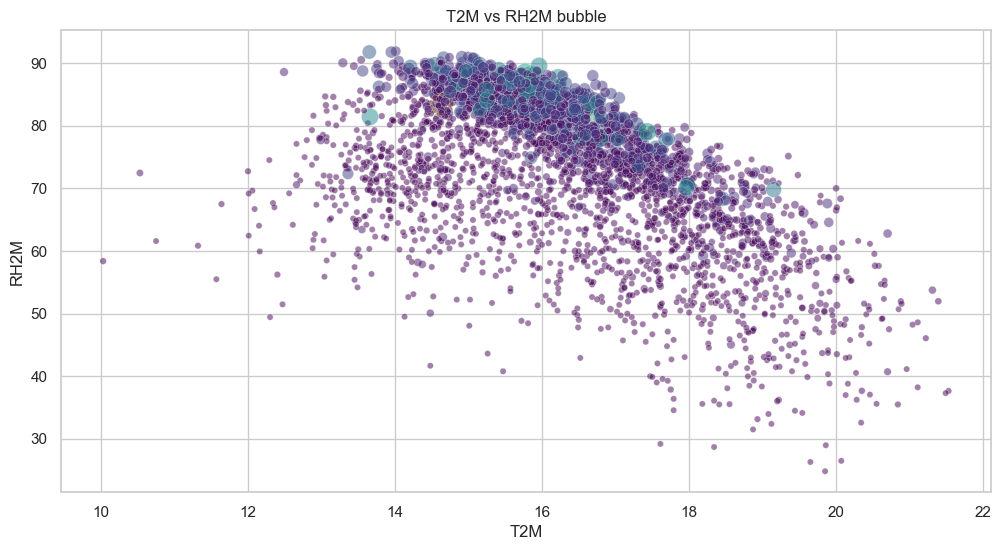

In [11]:
plt.figure()
df2 = df[df['PRECTOTCORR'] > 0]
sns.scatterplot(data=df2, x='T2M', y='RH2M', size='PRECTOTCORR', sizes=(20, 300), alpha=0.5, hue='PRECTOTCORR', palette='viridis', legend=False)
plt.title('T2M vs RH2M bubble')
plt.show()